In [1]:
import os
os.environ['JAX_ENABLE_X64'] = '1'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.2' 

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from temgym_core.utils import make_tilted_uniform_cube, project_phase_along_z
from temgym_core.gaussian import InterpolatedSample2D, square_input_wave, run_to_end_vmapped, Detector
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
from temgym_core.constants import energy2wavelength
jax.config.update("jax_enable_x64", True)
%matplotlib widget

In [2]:
cube_side_length_m = 100e-9
cube_fraction=0.25
N = 256

pixel_size = cube_side_length_m / N
detector = Detector(pixel_size=(pixel_size, pixel_size), shape=(N, N), z=0.0)

In [3]:
tilt_0 = jnp.deg2rad(0)  # 0 degrees
tilt_45 = jnp.deg2rad(45)  # 45 degrees
tilt_180 = jnp.deg2rad(180)  # 180 degrees

fields_0, x_coords_0, y_coords_0, z_coords_0 = make_tilted_uniform_cube(
    tilt_x=tilt_0,
    V0=10.0,
    B0=1.0,
    L=cube_side_length_m,
    cube_fraction=cube_fraction,
    amplitude_dampening=0.5,
    N=256,
)

fields_45, x_coords_45, y_coords_45, z_coords_45 = make_tilted_uniform_cube(
    tilt_x=tilt_45,
    V0=10.0,
    B0=1.0,
    L=cube_side_length_m,
    cube_fraction=cube_fraction,
    amplitude_dampening=0.5,
    N=256,
)
fields_180, x_coords_180, y_coords_180, z_coords_180 = make_tilted_uniform_cube(
    tilt_x=tilt_180,
    V0=10.0,
    B0=1.0,
    L=cube_side_length_m,
    cube_fraction=cube_fraction,
    amplitude_dampening=0.5,
    N=256,
)

In [5]:
dz = z_coords_0[1] - z_coords_0[0]
center_ix = N
center_iy = N

print(fields_0[32, 32, 33, 2])



0.0


In [6]:
voltage = 100e3  # in Volts
amp0, phi0 = project_phase_along_z(fields_0, z_coords_0, 100e3)
amp45, phi45 = project_phase_along_z(fields_45, z_coords_45, 100e3)
amp180, phi180 = project_phase_along_z(fields_180, z_coords_180, 100e3)
sample_2d_0 = amp0 * jnp.exp(1j * phi0)
sample_2d_45 = amp45 * jnp.exp(1j * phi45)
sample_2d_180 = amp180 * jnp.exp(1j * phi180)


Text(0.5, 0.98, 'Projected phase shifts from tilted cube sample with MIP and magnetic vector potential')

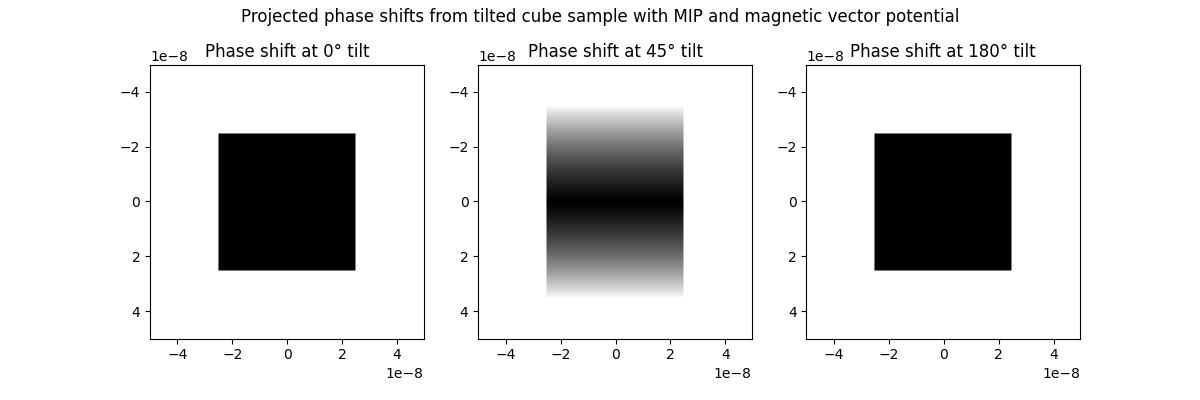

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(jnp.abs(jnp.flipud(sample_2d_0.T)), extent=detector.extent, cmap='gray')
axs[0].set_title('Phase shift at 0° tilt')
axs[1].imshow(jnp.abs(jnp.flipud(sample_2d_45.T)), extent=detector.extent, cmap='gray')
axs[1].set_title('Phase shift at 45° tilt')
axs[2].imshow(jnp.abs(jnp.flipud(sample_2d_180.T)), extent=detector.extent, cmap='gray')
axs[2].set_title('Phase shift at 180° tilt')
fig.suptitle('Projected phase shifts from tilted cube sample with MIP and magnetic vector potential')

In [8]:
wavelength = energy2wavelength(voltage)
k = 2 * jnp.pi / wavelength
sample = InterpolatedSample2D.from_array(sample=jnp.exp(1j * phi45 / k), x_coords=x_coords_45, y_coords=y_coords_45, z=0.0)

xy = jnp.meshgrid(x_coords_45, y_coords_45, indexing='ij')
x = xy[0].flatten()
y = xy[1].flatten()
xy = jnp.stack([x, y], axis=-1)


evaluated_phase_shift = jax.vmap(sample.phase_shift)(xy).reshape(len(x_coords_45), len(y_coords_45))

In [9]:

rays_in = square_input_wave(voltage=voltage,
                            aperture_length=cube_side_length_m,
                            waist=5e-10)

rays_out = run_to_end_vmapped(rays_in, (sample,))

field_out = evaluate_gaussians_gpu_kernel_wrapper(rays_out, detector)


/nobackup/dl277493/.pyenv/versions/JaxGym/lib/python3.12/site-packages/jax/_src/lax/lax.py:4791: ComplexWarning: Casting complex values to real discards the imaginary part
  x_bar = _convert_element_type(x_bar, x.aval.dtype, x.aval.weak_type)


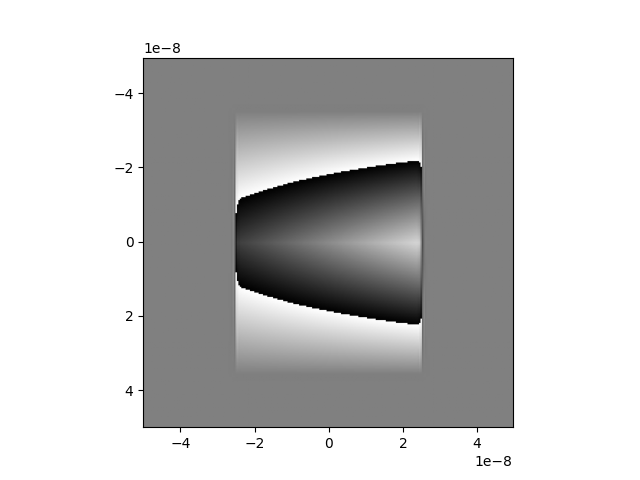

In [10]:
plt.figure()
plt.imshow(jnp.angle(field_out), extent=detector.extent, cmap='gray')
